# 2026 Summer DL — 5주차 과제 (CNN)

**24기 정지민**

---
# Step 1. 환경 설정

In [1]:
import os, time, random, copy, json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'      # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

SEED = 42

def set_seed(seed=SEED):
    """실험 간 비교가 의미를 가지려면 초기 가중치와 데이터 순서가 같아야 합니다."""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch  : {torch.__version__}")
print(f"device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

torch  : 2.12.0+cu126
device : cuda
GPU    : NVIDIA GeForce RTX 4070 Laptop GPU


---
# Step 2. 데이터

In [2]:
MEAN, STD = (0.2860,), (0.3530,)     # Fashion-MNIST의 실제 통계

tf_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

tf_aug = transforms.Compose([
    transforms.RandomCrop(28, padding=2),      # 위치를 흔들어 translation에 강하게
    transforms.RandomHorizontalFlip(p=0.5),    # label-preserving (4주차 p.18)
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

DATA_ROOT = "./data"
train_full_plain = datasets.FashionMNIST(DATA_ROOT, train=True,  download=True, transform=tf_plain)
train_full_aug   = datasets.FashionMNIST(DATA_ROOT, train=True,  download=True, transform=tf_aug)
test_set         = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=tf_plain)

CLASSES = train_full_plain.classes
print(CLASSES)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
N_TOTAL, N_VAL = len(train_full_plain), 6000
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N_TOTAL, generator=g).tolist()
val_idx, train_idx = perm[:N_VAL], perm[N_VAL:]

train_plain = Subset(train_full_plain, train_idx)   # augmentation 없는 학습셋
train_aug   = Subset(train_full_aug,   train_idx)   # augmentation 있는 학습셋 (인덱스 동일)
val_set     = Subset(train_full_plain, val_idx)

print(f"train {len(train_idx):,} / valid {len(val_idx):,} / test {len(test_set):,}")
print("validation 클래스별 개수:", np.bincount(np.array(train_full_plain.targets)[val_idx]))

train 54,000 / valid 6,000 / test 10,000
validation 클래스별 개수: [600 587 647 555 610 632 610 594 577 588]


C:\Users\jimin\AppData\Local\Temp\ipykernel_69300\2454059066.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print("validation 클래스별 개수:", np.bincount(np.array(train_full_plain.targets)[val_idx]))


In [4]:
BATCH_SIZE = 128
_pin = (device == "cuda")

def make_loaders(use_aug: bool):
    train_loader = DataLoader(train_aug if use_aug else train_plain,
                              batch_size=BATCH_SIZE, shuffle=True, pin_memory=_pin)
    val_loader   = DataLoader(val_set,  batch_size=512, shuffle=False, pin_memory=_pin)
    test_loader  = DataLoader(test_set, batch_size=512, shuffle=False, pin_memory=_pin)
    return train_loader, val_loader, test_loader

# 과적합 gap을 올바르게 재기 위한 "증강 없는" 학습셋 로더 (Step 4-3 참고)
clean_train_loader = DataLoader(train_plain, batch_size=512, shuffle=False, pin_memory=_pin)

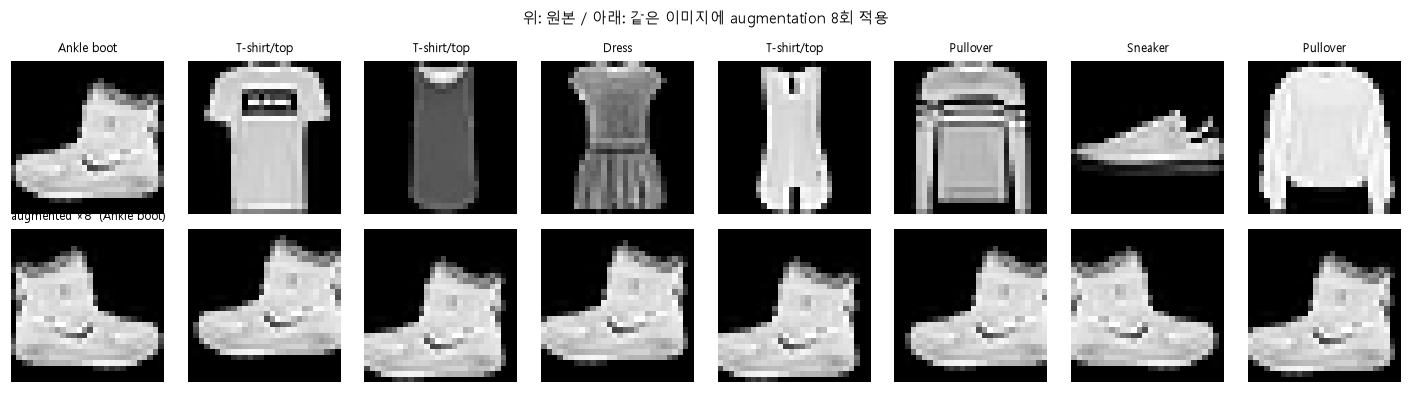

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
raw = datasets.FashionMNIST(DATA_ROOT, train=True, download=False)

for i, ax in enumerate(axes[0]):
    img, label = raw[i]
    ax.imshow(np.array(img), cmap='gray'); ax.set_title(CLASSES[label], fontsize=8); ax.axis('off')

img0, label0 = raw[0]
for ax in axes[1]:
    ax.imshow(tf_aug(img0).squeeze().numpy(), cmap='gray'); ax.axis('off')
axes[1][0].set_title(f"augmented ×8  ({CLASSES[label0]})", fontsize=8, loc='left')

plt.suptitle("위: 원본 / 아래: 같은 이미지에 augmentation 8회 적용", fontsize=10)
plt.tight_layout(); plt.show()

---
# Step 3. 모델

In [6]:
class ConvBlock(nn.Module):
    """block_type
         'double3' : conv3x3 -> conv3x3   (receptive field 5x5, ReLU 2회)
         'single5' : conv5x5              (receptive field 5x5, ReLU 1회)
       두 방식의 receptive field가 같으므로 5주차 p.59의 VGG 주장을 공정하게 비교할 수 있습니다.

       downsample
         'maxpool' / 'avgpool' : 블록 끝에 pooling
         'stride'              : 마지막 conv의 stride=2 (pooling 없음)
    """
    def __init__(self, in_ch, out_ch, use_bn=False, p_conv=0.0,
                 downsample='maxpool', block_type='double3'):
        super().__init__()
        s2 = 2 if downsample == 'stride' else 1
        b  = not use_bn                      # BN이 뒤따르면 bias는 상쇄되므로 제거

        if block_type == 'double3':
            self.convs = nn.ModuleList([
                nn.Conv2d(in_ch,  out_ch, 3, stride=1,  padding=1, bias=b),
                nn.Conv2d(out_ch, out_ch, 3, stride=s2, padding=1, bias=b),
            ])
        elif block_type == 'single5':
            self.convs = nn.ModuleList([
                nn.Conv2d(in_ch, out_ch, 5, stride=s2, padding=2, bias=b),
            ])
        else:
            raise ValueError(block_type)

        self.bns = nn.ModuleList([
            nn.BatchNorm2d(out_ch) if use_bn else nn.Identity() for _ in self.convs
        ])

        if   downsample == 'maxpool': self.pool = nn.MaxPool2d(2, 2)
        elif downsample == 'avgpool': self.pool = nn.AvgPool2d(2, 2)
        elif downsample == 'stride':  self.pool = nn.Identity()
        else: raise ValueError(downsample)

        self.drop = nn.Dropout2d(p_conv) if p_conv > 0 else nn.Identity()

    def forward(self, x):
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))
        return self.drop(self.pool(x))

In [7]:
class ConfigurableCNN(nn.Module):
    def __init__(self, num_classes=10, in_ch=1, channels=(32, 64, 128),
                 block_type='double3', use_bn=False, p_conv=0.0, p_fc=0.0,
                 downsample='maxpool', head='flatten', init='default'):
        super().__init__()
        self.cfg = dict(block_type=block_type, use_bn=use_bn, p_conv=p_conv, p_fc=p_fc,
                        downsample=downsample, head=head, init=init)

        blocks, c_prev = [], in_ch
        for c in channels:
            blocks.append(ConvBlock(c_prev, c, use_bn=use_bn, p_conv=p_conv,
                                    downsample=downsample, block_type=block_type))
            c_prev = c
        self.features = nn.Sequential(*blocks)

        drop_fc = nn.Dropout(p_fc) if p_fc > 0 else nn.Identity()

        if head == 'flatten':
            # downsample 방식에 따라 최종 feature map 크기가 달라지므로
            # 하드코딩(예: 4096) 대신 더미 입력으로 계산합니다.
            flat_dim = self._infer_flat_dim(in_ch)
            self.neck = nn.Identity()
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Linear(flat_dim, 256), nn.ReLU(inplace=True),
                drop_fc, nn.Linear(256, num_classes))

        elif head == 'gap':
            # 공간 차원을 평균으로 요약 -> FC 파라미터가 거의 사라짐
            self.neck = nn.AdaptiveAvgPool2d(1)
            self.classifier = nn.Sequential(nn.Flatten(), drop_fc,
                                            nn.Linear(c_prev, num_classes))

        elif head == 'conv1x1_gap':
            # 5주차 p.62 — 1x1 conv로 채널을 먼저 줄이고 GAP
            self.neck = nn.Sequential(
                nn.Conv2d(c_prev, 64, kernel_size=1, bias=not use_bn),
                nn.BatchNorm2d(64) if use_bn else nn.Identity(),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d(1))
            self.classifier = nn.Sequential(nn.Flatten(), drop_fc,
                                            nn.Linear(64, num_classes))
        else:
            raise ValueError(head)

        if init in ('he', 'xavier'):
            self._init_weights(init)

    @torch.no_grad()
    def _infer_flat_dim(self, in_ch, size=28):
        was = self.training; self.eval()
        d = self.features(torch.zeros(1, in_ch, size, size))
        self.train(was)
        return int(np.prod(d.shape[1:]))

    def _init_weights(self, kind):
        """4주차 p.31의 정의를 그대로 따릅니다.
             He     : Var[W] = 2 / n_in            -> mode='fan_in'
             Xavier : Var[W] = 2 / (n_in + n_out)  -> xavier_normal_
        """
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                if kind == 'he':
                    nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                else:
                    nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.neck(self.features(x)))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
def trace(tag, **kw):
    m = ConfigurableCNN(**kw); m.eval()
    x = torch.zeros(1, 1, 28, 28)
    shapes = []
    with torch.no_grad():
        for blk in m.features:
            x = blk(x); shapes.append(tuple(x.shape[1:]))
        x = m.neck(x)
    print(f"[{tag}]")
    print(f"   블록 출력 : {shapes}   -> neck 후 {tuple(x.shape[1:])}")
    print(f"   파라미터  : {count_params(m):,}\n")

trace("double3 + maxpool + flatten (기본)", use_bn=True)
trace("single5 + maxpool + flatten (C1)",  use_bn=True, block_type='single5')
trace("double3 + stride2  + flatten (C3)", use_bn=True, downsample='stride')
trace("double3 + maxpool + GAP     (C4)",  use_bn=True, head='gap')
trace("double3 + maxpool + 1x1+GAP (C5)",  use_bn=True, head='conv1x1_gap')

[double3 + maxpool + flatten (기본)]
   블록 출력 : [(32, 14, 14), (64, 7, 7), (128, 3, 3)]   -> neck 후 (128, 3, 3)
   파라미터  : 584,618

[single5 + maxpool + flatten (C1)]
   블록 출력 : [(32, 14, 14), (64, 7, 7), (128, 3, 3)]   -> neck 후 (128, 3, 3)
   파라미터  : 554,986

[double3 + stride2  + flatten (C3)]
   블록 출력 : [(32, 14, 14), (64, 7, 7), (128, 4, 4)]   -> neck 후 (128, 4, 4)
   파라미터  : 813,994

[double3 + maxpool + GAP     (C4)]
   블록 출력 : [(32, 14, 14), (64, 7, 7), (128, 3, 3)]   -> neck 후 (128, 1, 1)
   파라미터  : 288,170

[double3 + maxpool + 1x1+GAP (C5)]
   블록 출력 : [(32, 14, 14), (64, 7, 7), (128, 3, 3)]   -> neck 후 (64, 1, 1)
   파라미터  : 295,850



---
# Step 4. 학습 유틸리티

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience, self.min_delta, self.verbose = patience, min_delta, verbose
        self.best_score = np.inf
        self.best_epoch = -1
        self.counter = 0
        self.should_stop = False
        self.best_state = None
        self.fired = False          # patience 소진으로 실제 중단됐는지

    def step(self, score, model, epoch):
        """score: 낮을수록 좋은 값 (validation loss)"""
        if score < self.best_score - self.min_delta:
            self.best_score, self.best_epoch, self.counter = score, epoch, 0
            # GPU 텐서를 그대로 들고 있으면 메모리를 점유하므로 CPU로 복사
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = self.fired = True
                if self.verbose:
                    print(f"    >> EarlyStopping: {self.patience} epoch 개선 없음 "
                          f"(best epoch {self.best_epoch}, val_loss {self.best_score:.4f})")
        return self.should_stop

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
        return model

In [10]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):
    """optimizer가 있으면 학습, 없으면 평가."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    tot_loss, tot_correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out  = model(x)
            loss = criterion(out, y)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            bs = y.size(0)
            tot_loss    += loss.item() * bs
            tot_correct += (out.argmax(1) == y).sum().item()
            n += bs
    return tot_loss / n, tot_correct / n

In [11]:
@torch.no_grad()
def clean_train_acc(model):
    """eval() 모드 + 증강 없는 train set 기준 정확도 (val과 동일 조건)."""
    _, acc = run_epoch(model, clean_train_loader)
    return acc

In [12]:
def make_optimizer(model, name, lr, weight_decay=0.0):
    """weight decay를 걸 파라미터와 걸지 않을 파라미터를 분리 (BN γ·β, bias 제외)."""
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if (p.ndim <= 1 or n.endswith(".bias")) else decay).append(p)

    groups = [{'params': decay,    'weight_decay': weight_decay},
              {'params': no_decay, 'weight_decay': 0.0}]

    if   name == 'sgd_momentum': return torch.optim.SGD(groups, lr=lr, momentum=0.9)
    elif name == 'rmsprop':      return torch.optim.RMSprop(groups, lr=lr)
    elif name == 'adam':         return torch.optim.Adam(groups, lr=lr)    # L2 항 방식
    elif name == 'adamw':        return torch.optim.AdamW(groups, lr=lr)   # decoupled 방식
    raise ValueError(name)

DEFAULT_LR = {'sgd_momentum': 5e-2, 'rmsprop': 1e-3, 'adam': 1e-3, 'adamw': 1e-3}

In [13]:
MAX_EPOCHS = 20
PATIENCE   = 5

def fit(model, use_aug, optimizer='adam', lr=None, weight_decay=0.0,
        max_epochs=MAX_EPOCHS, patience=PATIENCE, tag=""):

    train_loader, val_loader, test_loader = make_loaders(use_aug)
    model = model.to(device)
    lr = DEFAULT_LR[optimizer] if lr is None else lr
    optim_ = make_optimizer(model, optimizer, lr, weight_decay)

    stopper = EarlyStopping(patience=patience)
    hist = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
    t0 = time.time()

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optim_)
        va_loss, va_acc = run_epoch(model, val_loader)
        hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
        hist['val_loss'].append(va_loss);   hist['val_acc'].append(va_acc)
        print(f"  [{tag}] epoch {epoch:2d}/{max_epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}")
        if stopper.step(va_loss, model, epoch):
            break

    model = stopper.restore(model).to(device)        # best epoch 가중치로 복원
    elapsed = time.time() - t0

    tr_clean = clean_train_acc(model)                # 올바른 gap 측정 (4-3)
    te_loss, te_acc = run_epoch(model, test_loader)

    result = dict(
        epochs_run=len(hist['val_loss']), best_epoch=stopper.best_epoch,
        best_val_loss=stopper.best_score, val_acc=hist['val_acc'][stopper.best_epoch - 1],
        train_acc_clean=tr_clean, gap=tr_clean - hist['val_acc'][stopper.best_epoch - 1],
        test_acc=te_acc, params=count_params(model), time_sec=elapsed,
        early_stopped=stopper.fired,
        budget_exhausted=(not stopper.fired),        # 예산을 다 쓰고 끝났는가
        optimizer=optimizer, lr=lr, weight_decay=weight_decay, use_aug=use_aug,
    )
    flag = "" if stopper.fired else "   [예산소진: 아직 개선 중]"
    print(f"  [{tag}] best epoch {result['best_epoch']} | val {result['val_acc']:.4f} | "
          f"test {te_acc:.4f} | clean train {tr_clean:.4f} | gap {result['gap']*100:+.2f}%p | "
          f"{elapsed:.0f}s{flag}\n")
    return model, hist, result

---
# Step 5. 그룹 A — 기법 누적 ablation

In [14]:
BASE = dict(num_classes=10, in_ch=1, channels=(32, 64, 128),
            block_type='double3', downsample='maxpool', head='flatten')

GROUP_A = [
    dict(name="A1_Baseline", desc="Baseline (기법 없음)",
         model=dict(use_bn=False, p_conv=0.0,  p_fc=0.0, init='default'),
         aug=False, optimizer='adam', wd=0.0),

    dict(name="A2_BN",       desc="+ BatchNorm",
         model=dict(use_bn=True,  p_conv=0.0,  p_fc=0.0, init='default'),
         aug=False, optimizer='adam', wd=0.0),

    dict(name="A3_He",       desc="+ He init (2/n_in)",
         model=dict(use_bn=True,  p_conv=0.0,  p_fc=0.0, init='he'),
         aug=False, optimizer='adam', wd=0.0),

    dict(name="A4_Dropout",  desc="+ Dropout",
         model=dict(use_bn=True,  p_conv=0.25, p_fc=0.5, init='he'),
         aug=False, optimizer='adam', wd=0.0),

    dict(name="A5_L2",       desc="+ L2 weight decay (Adam, λ=1e-4)",
         model=dict(use_bn=True,  p_conv=0.25, p_fc=0.5, init='he'),
         aug=False, optimizer='adam', wd=1e-4),

    dict(name="A6_Augment",  desc="+ Data Augmentation",
         model=dict(use_bn=True,  p_conv=0.25, p_fc=0.5, init='he'),
         aug=True,  optimizer='adam', wd=1e-4),
]

models, histories, results, meta = {}, {}, {}, {}

def run(exp):
    name = exp['name']
    print("=" * 76); print(f"{name}  |  {exp['desc']}"); print("=" * 76)
    set_seed(SEED)                                  # 매 실험 동일 조건에서 출발
    cfg = dict(BASE); cfg.update(exp['model'])
    model = ConfigurableCNN(**cfg)
    print(f"  파라미터: {count_params(model):,}")
    m, h, r = fit(model, use_aug=exp['aug'], optimizer=exp['optimizer'],
                  weight_decay=exp['wd'], tag=name)
    r['desc'] = exp['desc']
    models[name], histories[name], results[name], meta[name] = m, h, r, exp
    return r

for exp in GROUP_A:
    run(exp)
print("그룹 A 완료.")

A1_Baseline  |  Baseline (기법 없음)
  파라미터: 584,170


  [A1_Baseline] epoch  1/20 | train loss 0.5807 acc 0.7841 | val loss 0.3884 acc 0.8540


  [A1_Baseline] epoch  2/20 | train loss 0.3252 acc 0.8795 | val loss 0.3065 acc 0.8868


  [A1_Baseline] epoch  3/20 | train loss 0.2662 acc 0.9020 | val loss 0.2622 acc 0.9062


  [A1_Baseline] epoch  4/20 | train loss 0.2266 acc 0.9159 | val loss 0.2358 acc 0.9158


...

  [A6_Augment] epoch 17/20 | train loss 0.2508 acc 0.9098 | val loss 0.2085 acc 0.9253


  [A6_Augment] epoch 18/20 | train loss 0.2495 acc 0.9105 | val loss 0.2093 acc 0.9245


  [A6_Augment] epoch 19/20 | train loss 0.2480 acc 0.9100 | val loss 0.2042 acc 0.9265


  [A6_Augment] epoch 20/20 | train loss 0.2440 acc 0.9126 | val loss 0.2068 acc 0.9265


  [A6_Augment] best epoch 16 | val 0.9268 | test 0.9204 | clean train 0.9326 | gap +0.58%p | 418s   [예산소진: 아직 개선 중]

그룹 A 완료.


In [15]:
exp_xavier = dict(name="A3x_Xavier", desc="초기화 비교용: Xavier (A3와 초기화만 다름)",
                  model=dict(use_bn=True, p_conv=0.0, p_fc=0.0, init='xavier'),
                  aug=False, optimizer='adam', wd=0.0)
run(exp_xavier)

init_cmp = pd.DataFrame([{
    "초기화": lbl, "Var[W]": v,
    "val acc": round(results[n]['val_acc'], 4),
    "test acc": round(results[n]['test_acc'], 4),
    "best epoch": results[n]['best_epoch'],
} for n, lbl, v in [("A2_BN", "PyTorch 기본", "1/(3·n_in)"),
                    ("A3x_Xavier", "Xavier", "2/(n_in+n_out)"),
                    ("A3_He", "He", "2/n_in")]])
display(init_cmp)

A3x_Xavier  |  초기화 비교용: Xavier (A3와 초기화만 다름)
  파라미터: 584,618


  [A3x_Xavier] epoch  1/20 | train loss 0.4043 acc 0.8560 | val loss 0.2842 acc 0.8983


  [A3x_Xavier] epoch  2/20 | train loss 0.2420 acc 0.9112 | val loss 0.2671 acc 0.9062


  [A3x_Xavier] epoch  3/20 | train loss 0.1966 acc 0.9279 | val loss 0.2261 acc 0.9197


  [A3x_Xavier] epoch  4/20 | train loss 0.1691 acc 0.9373 | val loss 0.2334 acc 0.9212


...

  [A3x_Xavier] epoch  8/20 | train loss 0.0859 acc 0.9686 | val loss 0.2459 acc 0.9253


  [A3x_Xavier] epoch  9/20 | train loss 0.0776 acc 0.9719 | val loss 0.2597 acc 0.9222


  [A3x_Xavier] epoch 10/20 | train loss 0.0609 acc 0.9771 | val loss 0.2649 acc 0.9273
    >> EarlyStopping: 5 epoch 개선 없음 (best epoch 5, val_loss 0.2092)


  [A3x_Xavier] best epoch 5 | val 0.9282 | test 0.9227 | clean train 0.9642 | gap +3.61%p | 146s



,초기화,Var[W],val acc,test acc,best epoch
0,PyTorch 기본,1/(3·n_in),0.9300,0.9257,3
1,Xavier,2/(n_in+n_out),0.9282,0.9227,5
2,He,2/n_in,0.9177,0.9109,3


---
# Step 6. 그룹 B — Optimizer 비교

In [16]:
# 기준 모델은 validation 기준으로 선택 (test set은 최종 보고에만 사용)
BEST_A = max([e['name'] for e in GROUP_A], key=lambda n: results[n]['val_acc'])
base_exp = meta[BEST_A]
print(f"그룹 B·C 기준 모델: {BEST_A}  ({base_exp['desc']}, val acc {results[BEST_A]['val_acc']:.4f})")

GROUP_B = []
for nm, opt in [("B1_SGD_Momentum", 'sgd_momentum'), ("B2_RMSProp", 'rmsprop'),
                ("B4_AdamW", 'adamw')]:
    GROUP_B.append(dict(name=nm, desc=f"optimizer = {opt} (lr={DEFAULT_LR[opt]})",
                        model=base_exp['model'], aug=base_exp['aug'],
                        optimizer=opt, wd=(1e-2 if opt == 'adamw' else base_exp['wd'])))

for exp in GROUP_B:
    run(exp)

# B3 = 기준 모델(Adam) 결과를 그대로 사용
B_NAMES = ["B1_SGD_Momentum", "B2_RMSProp", BEST_A, "B4_AdamW"]
B_LABEL = {"B1_SGD_Momentum": "B1 SGD+Momentum (①관성)",
           "B2_RMSProp":      "B2 RMSProp (②적응 lr)",
           BEST_A:            f"B3 Adam (③둘 다) = {BEST_A}",
           "B4_AdamW":        "B4 AdamW (decoupled)"}
print("그룹 B 완료.")

그룹 B·C 기준 모델: A5_L2  (+ L2 weight decay (Adam, λ=1e-4), val acc 0.9338)
B1_SGD_Momentum  |  optimizer = sgd_momentum (lr=0.05)
  파라미터: 584,618


  [B1_SGD_Momentum] epoch  1/20 | train loss 0.7878 acc 0.7147 | val loss 0.3958 acc 0.8530


  [B1_SGD_Momentum] epoch  2/20 | train loss 0.4392 acc 0.8428 | val loss 0.3210 acc 0.8825


  [B1_SGD_Momentum] epoch  3/20 | train loss 0.3575 acc 0.8726 | val loss 0.2878 acc 0.9038


  [B1_SGD_Momentum] epoch  4/20 | train loss 0.3203 acc 0.8879 | val loss 0.2603 acc 0.9063


...

  [B4_AdamW] epoch 16/20 | train loss 0.1631 acc 0.9403 | val loss 0.2004 acc 0.9323


  [B4_AdamW] epoch 17/20 | train loss 0.1585 acc 0.9426 | val loss 0.2080 acc 0.9337


  [B4_AdamW] epoch 18/20 | train loss 0.1517 acc 0.9443 | val loss 0.2217 acc 0.9327


  [B4_AdamW] epoch 19/20 | train loss 0.1461 acc 0.9474 | val loss 0.2089 acc 0.9342
    >> EarlyStopping: 5 epoch 개선 없음 (best epoch 14, val_loss 0.1933)


  [B4_AdamW] best epoch 14 | val 0.9335 | test 0.9274 | clean train 0.9594 | gap +2.59%p | 290s

그룹 B 완료.


---
# Step 7. 그룹 C — Layer 변형

In [17]:
GROUP_C = [
    ("C1_Single5x5",  "3×3 두 번 → 5×5 한 번 (p.59)",      dict(block_type='single5')),
    ("C2_AvgPool",    "MaxPool → AvgPool (p.49)",          dict(downsample='avgpool')),
    ("C3_Stride2",    "MaxPool → stride 2 conv (p.43~45)", dict(downsample='stride')),
    ("C4_GAP",        "Flatten+FC → GAP (p.61)",           dict(head='gap')),
    ("C5_Conv1x1_GAP","GAP → 1×1 conv + GAP (p.62)",       dict(head='conv1x1_gap')),
]

for nm, desc, override in GROUP_C:
    exp = dict(name=nm, desc=desc,
               model={**base_exp['model'], **override},
               aug=base_exp['aug'], optimizer=base_exp['optimizer'], wd=base_exp['wd'])
    run(exp)

C_NAMES = [BEST_A] + [nm for nm, _, _ in GROUP_C]
print("그룹 C 완료.")

C1_Single5x5  |  3×3 두 번 → 5×5 한 번 (p.59)
  파라미터: 554,986


  [C1_Single5x5] epoch  1/20 | train loss 0.7455 acc 0.7328 | val loss 0.4193 acc 0.8403


  [C1_Single5x5] epoch  2/20 | train loss 0.4510 acc 0.8368 | val loss 0.3343 acc 0.8750


  [C1_Single5x5] epoch  3/20 | train loss 0.3809 acc 0.8620 | val loss 0.3026 acc 0.8878


  [C1_Single5x5] epoch  4/20 | train loss 0.3423 acc 0.8764 | val loss 0.2802 acc 0.8970


...

  [C5_Conv1x1_GAP] epoch 17/20 | train loss 0.2035 acc 0.9298 | val loss 0.2055 acc 0.9318


  [C5_Conv1x1_GAP] epoch 18/20 | train loss 0.1979 acc 0.9300 | val loss 0.1997 acc 0.9322


  [C5_Conv1x1_GAP] epoch 19/20 | train loss 0.1973 acc 0.9324 | val loss 0.2038 acc 0.9328


  [C5_Conv1x1_GAP] epoch 20/20 | train loss 0.1908 acc 0.9337 | val loss 0.2145 acc 0.9280


  [C5_Conv1x1_GAP] best epoch 16 | val 0.9312 | test 0.9259 | clean train 0.9524 | gap +2.12%p | 299s   [예산소진: 아직 개선 중]

그룹 C 완료.


---
# Step 8. 결과

In [18]:
def table(names, labels=None):
    rows = []
    for n in names:
        r = results[n]
        rows.append({
            "실험": labels[n] if labels else n,
            "설명": r['desc'],
            "파라미터": f"{r['params']:,}",
            "best ep": r['best_epoch'],
            "clean train": round(r['train_acc_clean'], 4),
            "val": round(r['val_acc'], 4),
            "test": round(r['test_acc'], 4),
            "gap(%p)": round(r['gap'] * 100, 2),
            "예산소진": "예" if r['budget_exhausted'] else "",
            "시간(s)": round(r['time_sec']),
        })
    return pd.DataFrame(rows)

pd.set_option('display.width', 220); pd.set_option('display.max_colwidth', 42)

print("━━━ 그룹 A : 4주차 기법 누적 ablation ━━━")
dfA = table([e['name'] for e in GROUP_A])
base_test = results['A1_Baseline']['test_acc']
dfA["A1대비(%p)"] = [round((results[e['name']]['test_acc'] - base_test) * 100, 2) for e in GROUP_A]
display(dfA)

━━━ 그룹 A : 4주차 기법 누적 ablation ━━━


,실험,설명,파라미터,best ep,clean train,val,test,gap(%p),예산소진,시간(s),A1대비(%p)
0,A1_Baseline,Baseline (기법 없음),"584,170",5,0.9413,0.9225,0.9161,1.88,,154,0.00
1,A2_BN,+ BatchNorm,"584,618",3,0.9521,0.9300,0.9257,2.21,,117,0.96
2,A3_He,+ He init (2/n_in),"584,618",3,0.9446,0.9177,0.9109,2.70,,117,-0.52
3,A4_Dropout,+ Dropout,"584,618",14,0.9601,0.9322,0.9289,2.79,,279,1.28
4,A5_L2,"+ L2 weight decay (Adam, λ=1e-4)","584,618",14,0.9575,0.9338,0.9264,2.36,,279,1.03
5,A6_Augment,+ Data Augmentation,"584,618",16,0.9326,0.9268,0.9204,0.58,예,418,0.43


In [19]:
print("━━━ 그룹 B : Optimizer 비교 (3주차 p.50) ━━━")
dfB = table(B_NAMES, B_LABEL)
dfB["lr"] = [results[n]['lr'] for n in B_NAMES]
display(dfB)

print("\n━━━ 그룹 C : Layer 변형 (5주차 CNN) ━━━")
dfC = table(C_NAMES, {**{BEST_A: f"C0 기준 ({BEST_A})"}, **{nm: nm for nm, _, _ in GROUP_C}})
c_base = results[BEST_A]['test_acc']; c_par = results[BEST_A]['params']
dfC["기준대비 test(%p)"] = [round((results[n]['test_acc'] - c_base) * 100, 2) for n in C_NAMES]
dfC["기준대비 파라미터"] = [f"{results[n]['params'] - c_par:+,}" for n in C_NAMES]
display(dfC)

━━━ 그룹 B : Optimizer 비교 (3주차 p.50) ━━━


,실험,설명,파라미터,best ep,clean train,val,test,gap(%p),예산소진,시간(s),lr
0,B1 SGD+Momentum (①관성),optimizer = sgd_momentum (lr=0.05),"584,618",14,0.9544,0.9328,0.9276,2.15,,284,0.050
1,B2 RMSProp (②적응 lr),optimizer = rmsprop (lr=0.001),"584,618",14,0.9596,0.9322,0.9268,2.74,,282,0.001
2,B3 Adam (③둘 다) = A5_L2,"+ L2 weight decay (Adam, λ=1e-4)","584,618",14,0.9575,0.9338,0.9264,2.36,,279,0.001
3,B4 AdamW (decoupled),optimizer = adamw (lr=0.001),"584,618",14,0.9594,0.9335,0.9274,2.59,,290,0.001



━━━ 그룹 C : Layer 변형 (5주차 CNN) ━━━


,실험,설명,파라미터,best ep,clean train,val,test,gap(%p),예산소진,시간(s),기준대비 test(%p),기준대비 파라미터
0,C0 기준 (A5_L2),"+ L2 weight decay (Adam, λ=1e-4)","584,618",14,0.9575,0.9338,0.9264,2.36,,279,0.00,+0
1,C1_Single5x5,3×3 두 번 → 5×5 한 번 (p.59),"554,986",18,0.9557,0.9237,0.9196,3.20,예,288,-0.68,"-29,632"
2,C2_AvgPool,MaxPool → AvgPool (p.49),"584,618",14,0.9560,0.9320,0.9295,2.40,,279,0.31,+0
3,C3_Stride2,MaxPool → stride 2 conv (p.43~45),"813,994",17,0.9641,0.9282,0.9252,3.60,예,294,-0.12,"+229,376"
4,C4_GAP,Flatten+FC → GAP (p.61),"288,170",20,0.9534,0.9338,0.9271,1.95,예,295,0.07,"-296,448"
5,C5_Conv1x1_GAP,GAP → 1×1 conv + GAP (p.62),"295,850",16,0.9524,0.9312,0.9259,2.12,예,299,-0.05,"-288,768"


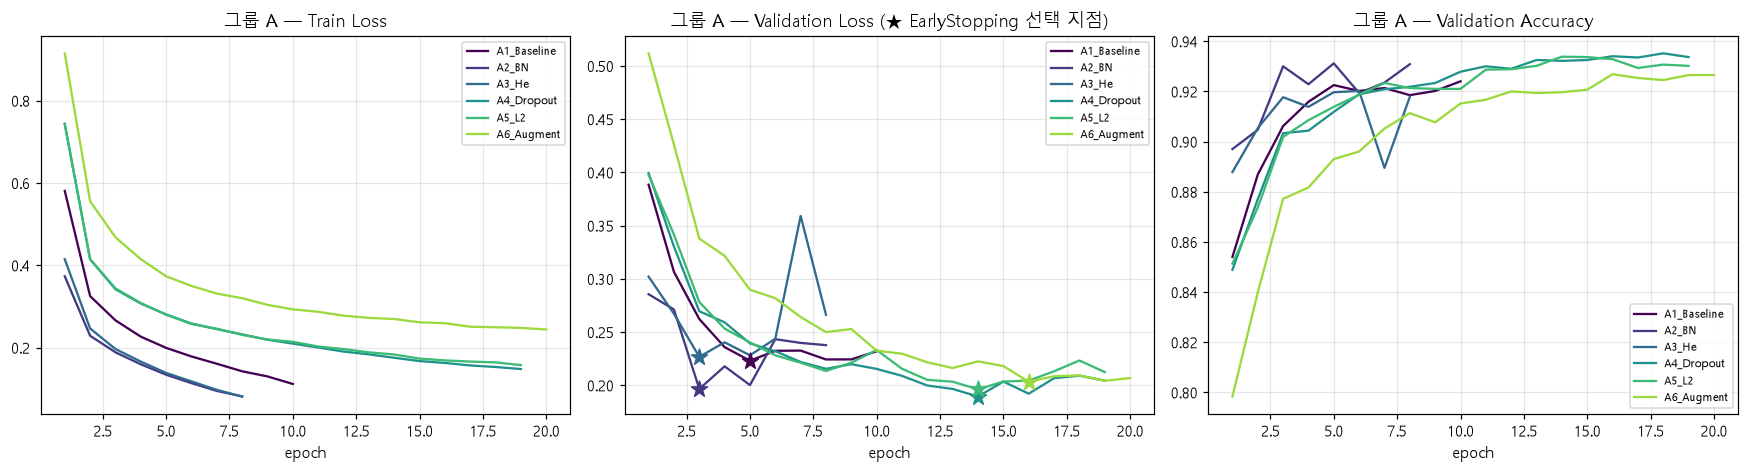

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(GROUP_A)))

for exp, c in zip(GROUP_A, colors):
    n, h = exp['name'], histories[exp['name']]
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['train_loss'], color=c, label=n)
    axes[1].plot(ep, h['val_loss'],   color=c, label=n)
    axes[2].plot(ep, h['val_acc'],    color=c, label=n)
    be = results[n]['best_epoch']
    axes[1].scatter([be], [h['val_loss'][be - 1]], color=c, marker='*', s=120, zorder=5)

axes[0].set_title("그룹 A — Train Loss")
axes[1].set_title("그룹 A — Validation Loss (★ EarlyStopping 선택 지점)")
axes[2].set_title("그룹 A — Validation Accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

C:\Users\jimin\AppData\Local\Temp\ipykernel_69300\499156861.py:32: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout(); plt.show()
C:\Users\jimin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


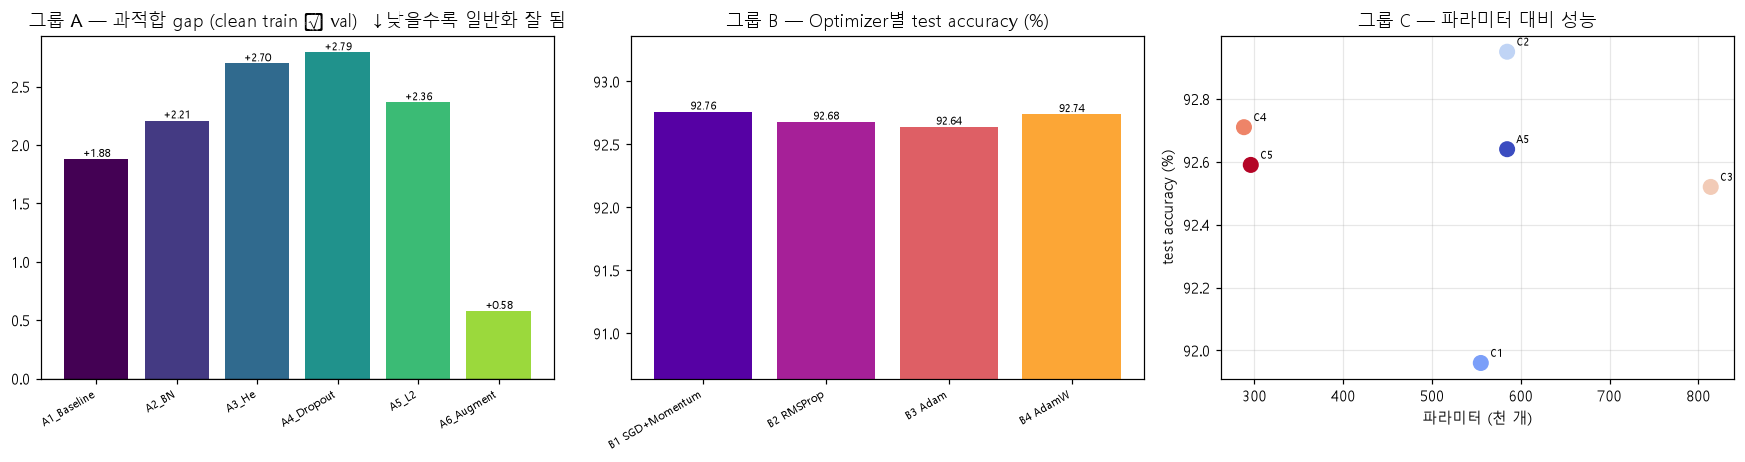

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

# (1) 그룹 A 과적합 gap
names = [e['name'] for e in GROUP_A]
gaps  = [results[n]['gap'] * 100 for n in names]
axes[0].bar(range(len(names)), gaps, color=colors)
axes[0].set_xticks(range(len(names))); axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=7)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title("그룹 A — 과적합 gap (clean train − val)  ↓낮을수록 일반화 잘 됨")
for i, v in enumerate(gaps):
    axes[0].text(i, v, f"{v:+.2f}", ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)

# (2) 그룹 B optimizer
bt = [results[n]['test_acc'] * 100 for n in B_NAMES]
axes[1].bar(range(len(B_NAMES)), bt, color=plt.cm.plasma(np.linspace(0.15, 0.8, len(B_NAMES))))
axes[1].set_xticks(range(len(B_NAMES)))
axes[1].set_xticklabels([B_LABEL[n].split(' (')[0] for n in B_NAMES], rotation=30, ha='right', fontsize=7)
axes[1].set_ylim(min(bt) - 2, max(bt) + 0.6); axes[1].set_title("그룹 B — Optimizer별 test accuracy (%)")
for i, v in enumerate(bt):
    axes[1].text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=7)

# (3) 그룹 C 파라미터 대비 정확도
axes[2].scatter([results[n]['params'] / 1000 for n in C_NAMES],
                [results[n]['test_acc'] * 100 for n in C_NAMES],
                s=90, c=plt.cm.coolwarm(np.linspace(0, 1, len(C_NAMES))), zorder=3)
for n in C_NAMES:
    axes[2].annotate(n.split('_')[0], (results[n]['params'] / 1000, results[n]['test_acc'] * 100),
                     textcoords="offset points", xytext=(6, 4), fontsize=7)
axes[2].set_xlabel("파라미터 (천 개)"); axes[2].set_ylabel("test accuracy (%)")
axes[2].set_title("그룹 C — 파라미터 대비 성능"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
# Step 9. 최종 모델 분석

최종 모델: A5_L2  |  + L2 weight decay (Adam, λ=1e-4)
  val 0.9338  /  test 0.9264


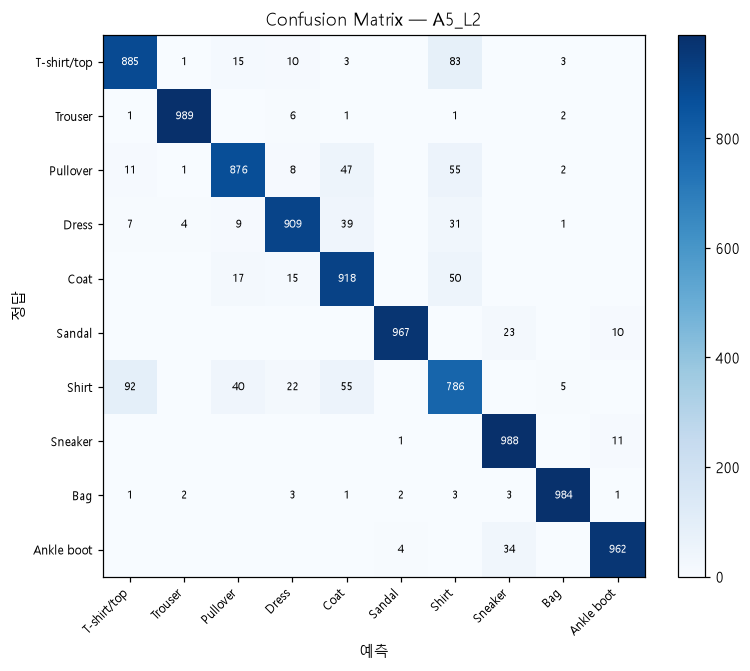

In [22]:
ALL = list(results.keys())
best_name  = max(ALL, key=lambda k: results[k]['val_acc'])     # ← validation 기준
best_model = models[best_name]
print(f"최종 모델: {best_name}  |  {results[best_name]['desc']}")
print(f"  val {results[best_name]['val_acc']:.4f}  /  test {results[best_name]['test_acc']:.4f}")

_, _, test_loader = make_loaders(use_aug=False)
best_model.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds.append(best_model(x.to(device)).argmax(1).cpu()); trues.append(y)
all_pred, all_true = torch.cat(preds).numpy(), torch.cat(trues).numpy()

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_true, all_pred):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel("예측"); ax.set_ylabel("정답"); ax.set_title(f"Confusion Matrix — {best_name}")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

In [23]:
per_class = cm.diagonal() / cm.sum(axis=1)
order = np.argsort(per_class)

rows = []
for i in order:
    off = cm[i].copy(); off[i] = -1            # 대각(정답)을 제외하고 최대 오분류 대상
    j = int(off.argmax())
    rows.append({"클래스": CLASSES[i], "정확도": round(per_class[i], 4),
                 "오류 수": int(cm[i].sum() - cm[i, i]),
                 "가장 많이 틀린 대상": CLASSES[j], "그 개수": int(cm[i, j])})
display(pd.DataFrame(rows))

UPPER = ['T-shirt/top', 'Pullover', 'Coat', 'Shirt']
ui = [CLASSES.index(c) for c in UPPER]
upper_err = int(sum(cm[i].sum() - cm[i, i] for i in ui))
total_err = int(len(all_true) - cm.diagonal().sum())
print(f"\n전체 오류 {total_err}건 중 상의 계열 4개 클래스가 {upper_err}건 "
      f"({upper_err/total_err*100:.1f}%)")
print(f"이 4개를 완벽히 맞혔다면 전체 정확도는 {(len(all_true)-(total_err-upper_err))/len(all_true)*100:.2f}%")

,클래스,정확도,오류 수,가장 많이 틀린 대상,그 개수
0,Shirt,0.786,214,T-shirt/top,92
1,Pullover,0.876,124,Shirt,55
2,T-shirt/top,0.885,115,Shirt,83
3,Dress,0.909,91,Coat,39
4,Coat,0.918,82,Shirt,50
5,Ankle boot,0.962,38,Sneaker,34
6,Sandal,0.967,33,Sneaker,23
7,Bag,0.984,16,Dress,3
8,Sneaker,0.988,12,Ankle boot,11
9,Trouser,0.989,11,Dress,6



전체 오류 736건 중 상의 계열 4개 클래스가 535건 (72.7%)
이 4개를 완벽히 맞혔다면 전체 정확도는 97.99%


오분류 736 / 10000  (7.36%)


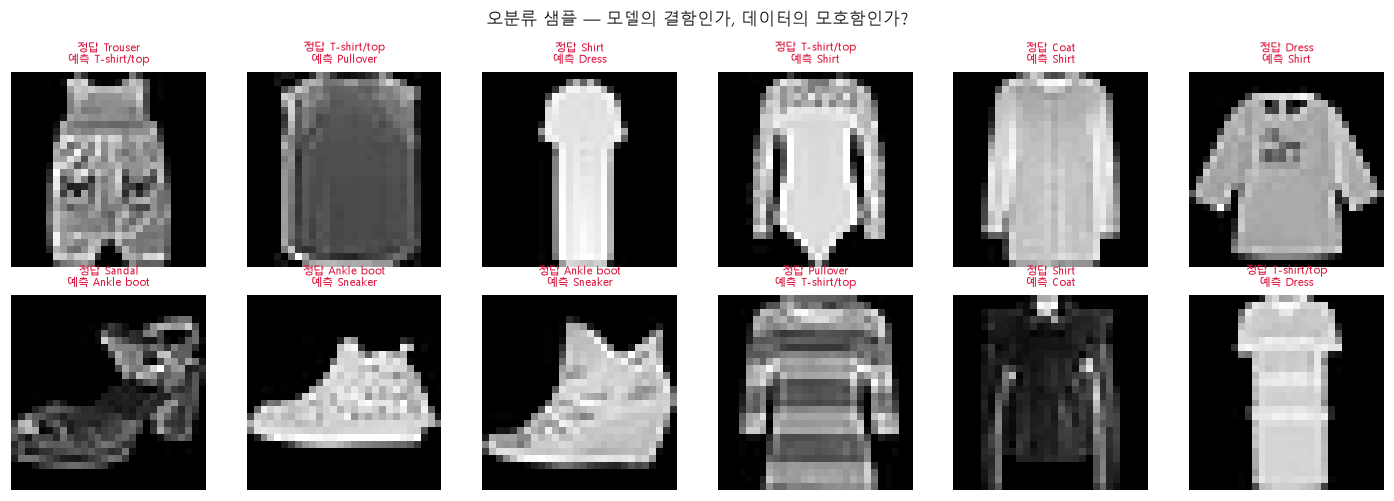

In [24]:
wrong = np.where(all_pred != all_true)[0]
print(f"오분류 {len(wrong)} / {len(all_true)}  ({len(wrong)/len(all_true)*100:.2f}%)")

pick = np.random.RandomState(0).choice(wrong, 12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for ax, idx in zip(axes.ravel(), pick):
    ax.imshow(test_set[idx][0].squeeze().numpy(), cmap='gray')
    ax.set_title(f"정답 {CLASSES[all_true[idx]]}\n예측 {CLASSES[all_pred[idx]]}",
                 fontsize=7.5, color='crimson')
    ax.axis('off')
plt.suptitle("오분류 샘플 — 모델의 결함인가, 데이터의 모호함인가?", fontsize=11)
plt.tight_layout(); plt.show()

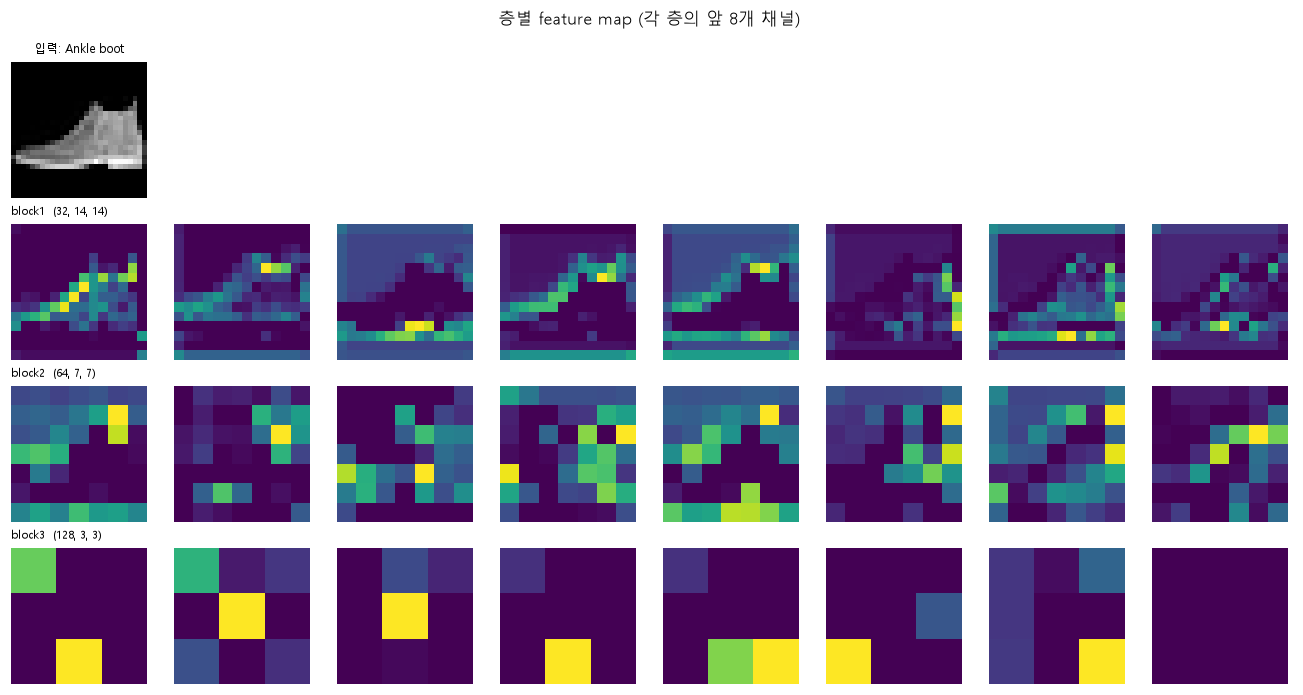

In [25]:
sample_img, sample_label = test_set[0]
acts = []
best_model.eval()
with torch.no_grad():
    h = sample_img.unsqueeze(0).to(device)
    for blk in best_model.features:
        h = blk(h); acts.append(h.cpu().squeeze(0))

n_show = 8
fig, axes = plt.subplots(len(acts) + 1, n_show, figsize=(12, 1.6 * (len(acts) + 1)))
axes[0][0].imshow(sample_img.squeeze(), cmap='gray')
axes[0][0].set_title(f"입력: {CLASSES[sample_label]}", fontsize=8)
for ax in axes[0]: ax.axis('off')
for r, a in enumerate(acts, start=1):
    for c in range(n_show):
        axes[r][c].imshow(a[c], cmap='viridis'); axes[r][c].axis('off')
    axes[r][0].set_title(f"block{r}  {tuple(a.shape)}", fontsize=7.5, loc='left')
plt.suptitle("층별 feature map (각 층의 앞 8개 채널)", fontsize=11)
plt.tight_layout(); plt.show()

---
# Step 10. 결과 분석


> 실험은 **한 번에 하나씩만 바꾸는** 원칙으로 세 그룹으로 나눠 수행했습니다 — A(기법 누적) / B(optimizer 교체) / C(layer 변형).
> B·C의 기준 모델과 최종 모델은 모두 validation으로 골랐습니다.

**최종 모델(validation 기준): A5_L2 — test 92.64%, baseline 대비 +1.03 %p**

| | 실험 | test | 파라미터 | gap(%p) | 비고 |
|---|---|---:|---:|---:|---|
| A | A1 Baseline | 91.61% | 584,170 | +1.88 | |
| A | A2 +BN | 92.57% | 584,618 | +2.21 | best epoch 5→3 |
| A | A3 +He | 91.09% | 584,618 | +2.70 | 통념과 반대 |
| A | A4 +Dropout | 92.89% | 584,618 | +2.79 | |
| A | A5 +L2 | 92.64% | 584,618 | +2.36 | **최종 모델** |
| A | A6 +Aug | 92.04% | 584,618 | **+0.58** | 예산소진 |
| B | SGD+Mom / RMSProp / Adam / AdamW | 92.76 / 92.68 / 92.64 / 92.74% | 584,618 | — | 차이 0.12%p 이내 |
| C | C1 5×5 한 번 | 91.96% | 554,986 | +3.20 | 예산소진 |
| C | C2 AvgPool | **92.95%** | 584,618 | +2.40 | test 최고 |
| C | C3 stride 2 | 92.52% | **813,994** | +3.60 | 예산소진 |
| C | C4 GAP | 92.71% | **288,170** | **+1.95** | 예산소진 |
| C | C5 1×1+GAP | 92.59% | 295,850 | +2.12 | 예산소진 |

## 핵심 발견

**1. BatchNorm이 비용 대비 효과가 가장 컸다.** 파라미터 0.08%(448개) 추가로 +0.96 %p.
정확도보다 **수렴 속도**의 변화가 큽니다 — best epoch 5→3, EarlyStopping이 빨리 걸려
총 학습 시간이 154s → 117s로 오히려 줄었습니다. 최적화를 쉽게 만드는 기법이라는 설명과 일치합니다.

**2. GAP은 파라미터를 51% 줄이면서 성능을 유지했다** (584,618 → 288,170, test +0.07 %p).
FC head(`1152→256→10`)가 297,738개인데 GAP은 1,290개로 끝납니다. gap도 2.36 → 1.95 %p로 개선됐습니다.

**3. "ReLU에는 He"가 성립하지 않았다.** val 기준 기본 0.9300 / Xavier 0.9282 / **He 0.9177**.
BN을 꺼도 결과가 같아(0.9225 / 0.9243 / 0.9170) "BN이 초기화 효과를 지웠다"는 가설은 기각됩니다.
He는 **깊은 망의 분산 감쇠**를 보상하는 기법인데 이 모델은 conv가 6층뿐이라,
보상할 감쇠가 없는 상태에서 분산만 6배 키운 셈으로 보입니다. **기법에는 성립 조건이 있습니다.**

**4. Dropout은 과적합을 줄이지 않았다 — 성능을 올렸을 뿐이다.**
gap이 +2.21 → +2.79 %p로 **늘었는데** test는 +0.32 %p 올랐습니다.
best epoch가 3 → 14로 밀려 더 오래 학습한 결과입니다.
gap을 실제로 줄인 것은 **augmentation뿐**(+2.36 → +0.58 %p)이었습니다.

**5. Optimizer 선택은 거의 무관했다.** 4종의 test 차이가 0.12 %p 이내이고 best epoch도 모두 14였습니다.
Adam+L2와 AdamW도 구분되지 않았습니다. 작은 모델에서는 옵티마이저보다
**구조(BN, GAP)를 손보는 편이 효과적**입니다.

**6. stride 2 conv가 파라미터를 39% 늘렸다.** MaxPool은 7→3이지만 stride 2 conv는
`⌊(7+2−3)/2⌋+1 = 4`를 남겨, flatten 차원이 1,152 → 2,048이 되고 FC가 그만큼 팽창합니다.
다운샘플링 비용은 그 층만이 아니라 **뒤에 오는 head와 함께** 봐야 합니다.

## 한계

- **20 epoch 상한이 6개 실험에 부족**했습니다(`예산소진`). 이들의 숫자는 최종 성능이 아닙니다.
- **seed 1개**로만 측정해, 0.1~0.3 %p 차이(그룹 B, C2)는 유의미하다고 볼 수 없습니다.
- He가 나빴던 원인 중 "얕은 망" 가설은 층 수를 바꿔 가며 비교해야 확정할 수 있습니다.